In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, RobertaModel, RobertaTokenizer
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import math
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.cluster import DBSCAN
from sklearn.utils.class_weight import compute_class_weight
import json
import openai

In [ ]:
from google.colab import drive
drive.mount('/content/drive/',force_remount=False)

Mounted at /content/drive/


In [ ]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part4 feature-engineering/leetcode_questions_df.csv')

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            61834 non-null  object 
 1   country                             61834 non-null  object 
 2   contest_url                         61834 non-null  object 
 3   num_of_contest                      61834 non-null  int64  
 4   is_weekly                           61834 non-null  bool   
 5   rank                                61834 non-null  int64  
 6   score                               61834 non-null  int64  
 7   question_number                     61834 non-null  int64  
 8   question_language                   61834 non-null  object 
 9   question_code                       61834 non-null  object 
 10  number_of_lines                     61834 non-null  int64  
 11  names_set                           61834

In [ ]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'java']
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_number'] > 2]
leetcode_questions_df = leetcode_questions_df.drop_duplicates(subset=['question_code'])
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['country'].isin(leetcode_questions_df['country'].value_counts().head(2).index)]

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2101 entries, 524 to 61818
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            2101 non-null   object 
 1   country                             2101 non-null   object 
 2   contest_url                         2101 non-null   object 
 3   num_of_contest                      2101 non-null   int64  
 4   is_weekly                           2101 non-null   bool   
 5   rank                                2101 non-null   int64  
 6   score                               2101 non-null   int64  
 7   question_number                     2101 non-null   int64  
 8   question_language                   2101 non-null   object 
 9   question_code                       2101 non-null   object 
 10  number_of_lines                     2101 non-null   int64  
 11  names_set                           2101 non-

In [ ]:
leetcode_questions_df.country.value_counts()

,count
country,
India,1392
United States,709


In [ ]:
leetcode_questions_df.describe()

,num_of_contest,rank,score,question_number,number_of_lines,token_count,variables_count,function_count,loop_count,condition_count,...,function_density,loop_density,condition_density,comment_tokens_density,contest_finish_time_total_seconds,question_finish_time_total_seconds,time_spent_per_question,global_rank_percentile,question_code_length,num_contests_participated
count,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,...,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000,2101.000000
mean,298.300333,648.926702,15.737268,3.388862,79.356021,47.513089,25.798191,4.271299,4.756782,6.839124,...,0.052998,0.085319,0.113994,0.103521,3580.056640,2664.263684,1283.543075,0.020029,2283.802951,7.831509
std,120.002451,338.665138,2.919799,0.487608,274.912947,64.347623,37.331363,20.736572,13.753973,22.838101,...,0.039611,0.063768,0.074739,0.178514,1530.215724,1307.602122,919.824590,0.055045,7921.391290,6.664417
min,116.000000,2.000000,8.000000,3.000000,6.000000,12.000000,4.000000,1.000000,0.000000,0.000000,...,0.006993,0.000000,0.000000,0.000000,371.000000,164.000000,0.000000,0.000001,144.000000,1.000000
25%,125.000000,370.000000,12.000000,3.000000,31.000000,30.000000,16.000000,1.000000,1.000000,2.000000,...,0.030303,0.040000,0.064516,0.000000,2310.000000,1557.000000,614.000000,0.000525,922.000000,2.000000
50%,374.000000,664.000000,17.000000,3.000000,45.000000,38.000000,21.000000,2.000000,3.000000,4.000000,...,0.043478,0.075472,0.102804,0.000000,3596.000000,2487.000000,1089.000000,0.002565,1325.000000,6.000000
75%,384.000000,934.000000,18.000000,4.000000,64.000000,47.000000,26.000000,3.000000,5.000000,6.000000,...,0.063830,0.111111,0.150943,0.166667,4872.000000,3632.000000,1726.000000,0.011130,1856.000000,12.000000
max,390.000000,1225.000000,20.000000,4.000000,2861.000000,661.000000,389.000000,213.000000,146.000000,250.000000,...,0.433333,0.521739,0.645833,0.902439,8568.000000,5399.000000,5219.000000,0.828094,82658.000000,29.000000


In [ ]:
model_name = "neulab/codebert-java"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaModel.from_pretrained(model_name)

code_snippets = leetcode_questions_df.question_code.tolist()

# Step 1: Encode the code snippets using CodeBERT
def get_embeddings(code_snippet):
    inputs = tokenizer(code_snippet, return_tensors='pt', truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    # Use the last hidden state of the [CLS] token as the embedding
    return outputs.last_hidden_state[:, 0, :].numpy()

# Get embeddings for all code snippets
embeddings = np.vstack([get_embeddings(snippet) for snippet in code_snippets])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.54k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/696 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at neulab/codebert-java and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [ ]:
min_samples = 10 ** (math.floor(math.log10(len(code_snippets))) - 1)

min_samples

100

In [ ]:
# Step 2: Apply DBSCAN for clustering and outlier detection
dbscan = DBSCAN(eps=0.05, min_samples=min_samples, metric='cosine', n_jobs=-1)
db_labels = dbscan.fit_predict(embeddings)

# Step 3: Identify and handle outliers
outliers = np.where(db_labels == -1)[0]

# Output some statistics
print(f'Removed {len(outliers)} outliers.')
print(f'Retained {len(db_labels) - len(outliers)} code snippets.')

Removed 80 outliers.
Retained 2021 code snippets.


In [ ]:
# Remove outliers from the DataFrame
leetcode_questions_df.reset_index(drop=True, inplace=True)
leetcode_questions_df = leetcode_questions_df[~leetcode_questions_df.index.isin(outliers)]

leetcode_questions_df.country.value_counts()

,count
country,
India,1322
United States,699


In [ ]:
X=leetcode_questions_df.drop('country',axis=1)
Y=leetcode_questions_df.country

In [ ]:
X.question_number = X.question_number.astype("category")

In [ ]:
X_train_text, X_test_text, Y_train, y_test = train_test_split(X.question_code, Y, test_size=0.2, random_state=0,stratify=Y)

In [ ]:
X_train_text, X_valid_text, y_train, y_valid = train_test_split(X_train_text, Y_train, test_size=0.125, random_state=0,stratify=Y_train)

In [ ]:
df = pd.concat([X_train_text, y_train], axis=1)

system_prompt = (
    "You are a code style profiler trained to classify programming styles based on regional educational patterns and stylistic conventions. "
    "This task is part of a research simulation in computational authorship profiling. "
    "Your goal is to assign each code snippet to either 'United States' or 'India', based purely on stylistic markers associated with common programming habits observed in datasets from these regions. "
    "These habits may include variable naming conventions (e.g., camelCase vs snake_case), commenting frequency and phrasing, spacing and indentation preferences, control structure usage, verbosity, and structural choices. "
    "You should not consider the semantic content of the code or attempt to infer nationality in a literal or personal sense. "
    "This classification is purely symbolic and intended for academic analysis of code expression patterns. "
    "Always respond with exactly one of the two labels: 'United States' or 'India'. "
    "If the style is ambiguous, choose the label that best aligns with the overall structure and conventions observed."
)


conversations = []

for _, row in df.iterrows():
    user_message = (
    "Below is a code snippet. Based on its stylistic and structural characteristics only—not its logic or content—"
    "please classify it as either originating from the 'United States' or from 'India'. "
    "Focus on naming patterns, spacing, indentation, comment style, and control flow formatting.\n\n"
    "Code:\n"
    f"{row['question_code']}"
    )

    assistant_response = row["country"]

    conversation = {
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_message},
            {"role": "assistant", "content": assistant_response}
        ]
    }
    conversations.append(conversation)

with open("training_data.jsonl", "w") as f:
    for convo in conversations:
        f.write(json.dumps(convo) + "\n")


In [ ]:
df = pd.concat([X_valid_text, y_valid], axis=1)

system_prompt = (
    "You are a code style profiler trained to classify programming styles based on regional educational patterns and stylistic conventions. "
    "This task is part of a research simulation in computational authorship profiling. "
    "Your goal is to assign each code snippet to either 'United States' or 'India', based purely on stylistic markers associated with common programming habits observed in datasets from these regions. "
    "These habits may include variable naming conventions (e.g., camelCase vs snake_case), commenting frequency and phrasing, spacing and indentation preferences, control structure usage, verbosity, and structural choices. "
    "You should not consider the semantic content of the code or attempt to infer nationality in a literal or personal sense. "
    "This classification is purely symbolic and intended for academic analysis of code expression patterns. "
    "Always respond with exactly one of the two labels: 'United States' or 'India'. "
    "If the style is ambiguous, choose the label that best aligns with the overall structure and conventions observed."
)


conversations = []

for _, row in df.iterrows():
    user_message = (
    "Below is a code snippet. Based on its stylistic and structural characteristics only—not its logic or content—"
    "please classify it as either originating from the 'United States' or from 'India'. "
    "Focus on naming patterns, spacing, indentation, comment style, and control flow formatting.\n\n"
    "Code:\n"
    f"{row['question_code']}"
    )

    assistant_response = row["country"]

    conversation = {
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_message},
            {"role": "assistant", "content": assistant_response}
        ]
    }
    conversations.append(conversation)

with open("validation_data.jsonl", "w") as f:
    for convo in conversations:
        f.write(json.dumps(convo) + "\n")


# Finetuned GPT 4 nano

In [ ]:
MODEL_NAME = "ft:gpt-4.1-nano-2025-04-14:personal:java-country:BdHMNWoQ"
API_KEY = ""

client = openai.OpenAI(api_key=API_KEY)

In [ ]:
def get_finetuned_llm_prediction(code):
  response = client.chat.completions.create(
      model=MODEL_NAME,
      messages=[
                  {"role": "system", "content": system_prompt},
                  {"role": "user", "content": (
                                    "Below is a code snippet. Based on its stylistic and structural characteristics only—not its logic or content—"
                                    "please classify it as either originating from the 'United States' or from 'India'. "
                                    "Focus on naming patterns, spacing, indentation, comment style, and control flow formatting.\n\n"
                                    "Code:\n"
                                    f"{code}"
                                    )}
               ],
  )

  return response.choices[0].message.content

In [ ]:
y_test_llm = X_test_text.apply(get_finetuned_llm_prediction)

In [ ]:
y_test_llm.drop(1942, inplace=True)
y_test.drop(1942, inplace=True)

               precision    recall  f1-score   support

        India       0.82      0.89      0.85       265
United States       0.75      0.62      0.68       139

     accuracy                           0.80       404
    macro avg       0.79      0.76      0.77       404
 weighted avg       0.80      0.80      0.79       404

f1_score_macro :  0.7669479756436278
f1_score_weighted :  0.7941147228706419


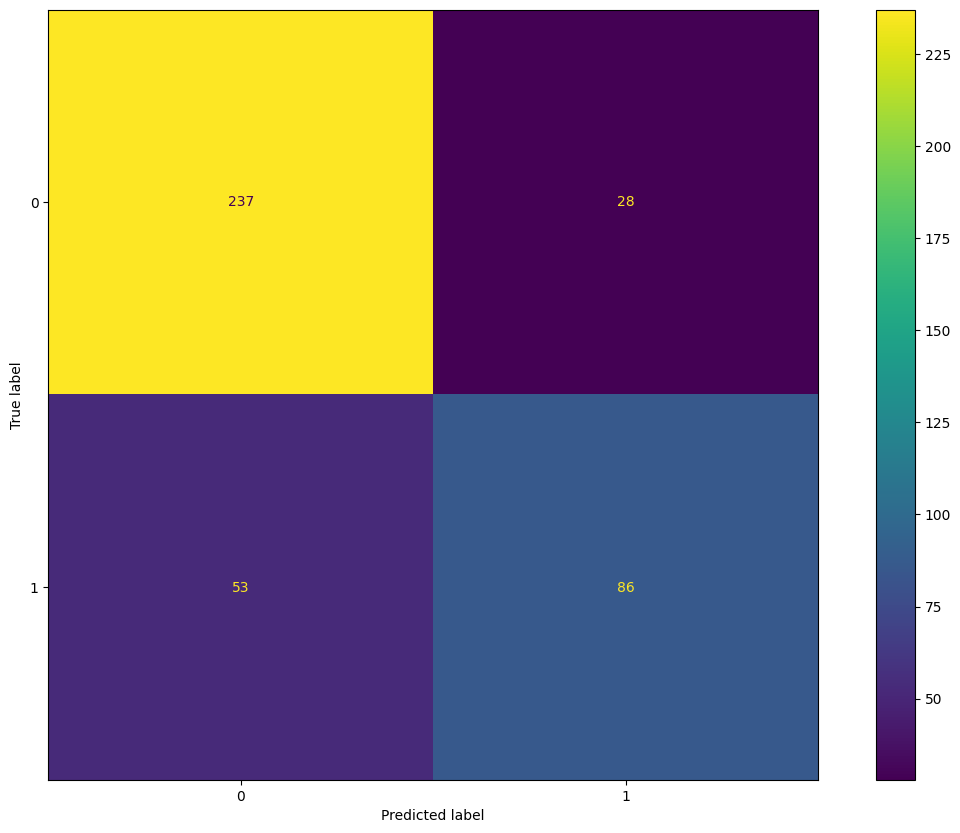

In [ ]:
print(classification_report(y_test, y_test_llm))

print("f1_score_macro : ",f1_score(y_test, y_test_llm, average='macro'))
print("f1_score_weighted : ",f1_score(y_test, y_test_llm, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_test_llm))

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()